# Домашнее задание
## Задача 1
Построить модель линейной регрессии.
- линейная модель
- полином второй степени
- полином третьей степени
- экспонента 


Построить графики получившихся функций (линейная, квадратичная, кубическая, экспонента) и тренировочной выборки. 
- Посчитать MSE для каждого случая
- Выбрать наилучший вариант (без тестовой выборки)


Для решения можете использовать np.linalg.lstsq, np.polyfit, np.poly1d, scipy.stats.linregress, scipy.optimize.curve_fit, sklearn.linear_model.LinearRegression, statsmodels, np.linalg.solve (аналитически) или с помощью стохастического градиентного спуска (написать самостоятельно).

# Линейная модель

## Вариант 1

In [1168]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [1169]:
y = np.array([12.19, 8.41, 14.68, 8.64, 32.94, 22.61, 45.92, 23.63, 18.59, 36.22, 50.10, 46.22, 23.63, 47.30, 40.03, 56.53, 38.41, 51.47, 6.29, 35.41, 67.79, 74.21, 79.12, 45.10])
x = np.linspace(0, 1, num = 24)

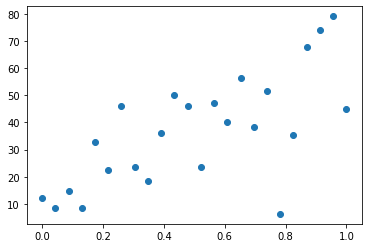

In [1170]:
plt.scatter(x, y);

In [1171]:
X = list(zip(np.ones(24), x))

In [1172]:
W = np.linalg.lstsq(X, y, rcond=None)[0]

In [1173]:
def f(x, w): 
    return w[0] + w[1]*x

In [1174]:
f(x, W)

array([13.63803333, 15.66023333, 17.68243333, 19.70463333, 21.72683333,
       23.74903333, 25.77123333, 27.79343333, 29.81563333, 31.83783333,
       33.86003333, 35.88223333, 37.90443333, 39.92663333, 41.94883333,
       43.97103333, 45.99323333, 48.01543333, 50.03763333, 52.05983333,
       54.08203333, 56.10423333, 58.12643333, 60.14863333])

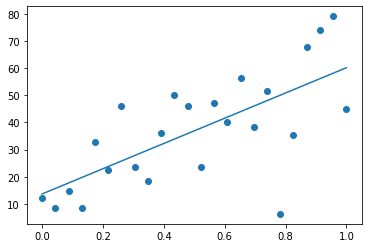

In [1175]:
plt.scatter(x, y)
plt.plot(x, f(x, W));

In [1176]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, f(x, W)))

Среднеквадратичная ошибка: 213.13469863888886


## Вариант 2

In [1177]:
x = np.linspace(0, 1, num = 24).reshape((-1, 1))
model = LinearRegression()
model.fit(x, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [1178]:
a = model.coef_[0]
b = model.intercept_
print('Наклон линии (угловой коэффициент): ', a)
print('Точка пересечения (с осью Y): ', b)

Наклон линии (угловой коэффициент):  46.510600000000004
Точка пересечения (с осью Y):  13.638033333333329


In [1179]:
lin_reg = a*x + b

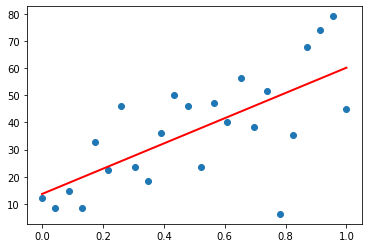

In [1180]:
plt.scatter(x, y)
plt.plot(x, lin_reg, color='red', linewidth=2);

In [1181]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, lin_reg))

Среднеквадратичная ошибка: 213.13469863888892


# Полином второй степени

## Вариант 1

In [1182]:
y = np.array([12.19, 8.41, 14.68, 8.64, 32.94, 22.61, 45.92, 23.63, 18.59, 36.22, 50.10, 46.22, 23.63, 47.30, 40.03, 56.53, 38.41, 51.47, 6.29, 35.41, 67.79, 74.21, 79.12, 45.10])
x = np.linspace(0, 1, num = 24)

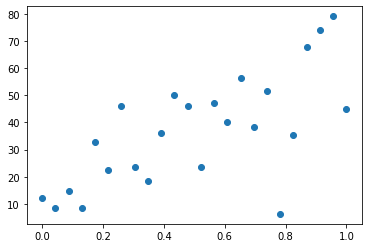

In [1183]:
plt.scatter(x, y);

In [1184]:
X = list(zip(np.ones(24), x, x*x))

In [1185]:
W = np.linalg.lstsq(X, y, rcond=None)[0]
print (W)

[12.1867     55.61441818 -9.10381818]


In [1186]:
def f(x, w): 
    return w[0] + w[1]*x + w[2]*x*x

In [1187]:
f(x, W)

array([12.1867    , 14.5875087 , 16.95389842, 19.28586917, 21.58342095,
       23.84655375, 26.07526759, 28.26956245, 30.42943834, 32.55489526,
       34.6459332 , 36.70255217, 38.72475217, 40.7125332 , 42.66589526,
       44.58483834, 46.46936245, 48.31946759, 50.13515375, 51.91642095,
       53.66326917, 55.37569842, 57.0537087 , 58.6973    ])

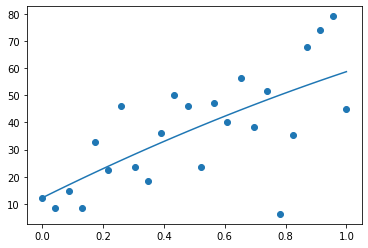

In [1188]:
plt.scatter(x, y)
plt.plot(x, f(x, W));

In [1189]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, f(x, W)))

Среднеквадратичная ошибка: 212.59353678557315


## Вариант 2

In [1190]:
X = np.polyfit(x,y,2)
print(X)

[-9.10381818 55.61441818 12.1867    ]


In [1191]:
pol_sec_deg = X[2] + X[1]*x + X[0]*x*x

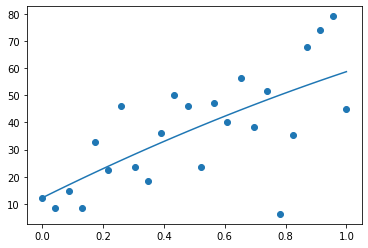

In [1192]:
plt.scatter(x, y)
plt.plot(x, pol_sec_deg);

In [1193]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, pol_sec_deg))

Среднеквадратичная ошибка: 212.5935367855731


# Полином третьей степени

## Вариант 1

In [1194]:
y = np.array([12.19, 8.41, 14.68, 8.64, 32.94, 22.61, 45.92, 23.63, 18.59, 36.22, 50.10, 46.22, 23.63, 47.30, 40.03, 56.53, 38.41, 51.47, 6.29, 35.41, 67.79, 74.21, 79.12, 45.10])
x = np.linspace(0, 1, num = 24)

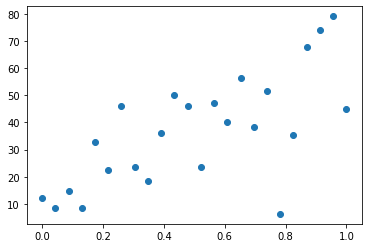

In [1195]:
plt.scatter(x, y);

In [1196]:
X = list(zip(np.ones(24), x, x*x, x*x*x))

In [1197]:
W = np.linalg.lstsq(X, y, rcond=None)[0]
print (W)

[   5.65033333  143.52996465 -233.63225758  149.68562626]


In [1198]:
def f(x, w): 
    return w[0] + w[1]*x + w[2]*x*x + w[3]*x*x*x

In [1199]:
f(x, W)

array([ 5.65033333, 11.46142029, 16.46302503, 20.72896311, 24.33305007,
       27.34910145, 29.85093281, 31.91235968, 33.60719763, 35.00926219,
       36.19236891, 37.23033333, 38.19697101, 39.1660975 , 40.21152833,
       41.40707905, 42.82656522, 44.54380237, 46.63260606, 49.16679183,
       52.22017523, 55.86657181, 60.1797971 , 65.23366667])

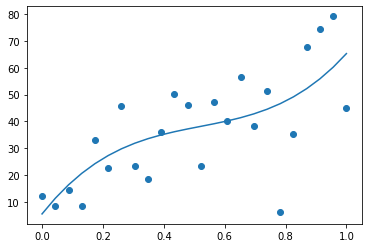

In [1200]:
plt.scatter(x, y)
plt.plot(x, f(x, W));

In [1201]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, f(x, W)))

Среднеквадратичная ошибка: 202.513036590909


## Вариант 2

In [1202]:
X = np.polyfit(x,y,3)
print(X)

[ 149.68562626 -233.63225758  143.52996465    5.65033333]


In [1203]:
pol_thrd_deg = X[3] + X[2]*x + X[1]*x*x + X[0]*x*x*x

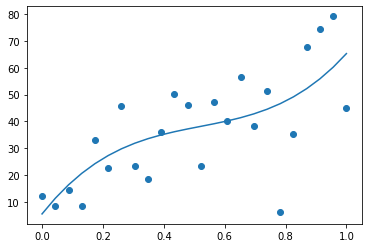

In [1204]:
plt.scatter(x, y)
plt.plot(x, pol_thrd_deg);

In [1205]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, pol_thrd_deg))

Среднеквадратичная ошибка: 202.51303659090914


# Экспоненциальная регрессия

## Вариант 1

In [1206]:
y = np.array([12.19, 8.41, 14.68, 8.64, 32.94, 22.61, 45.92, 23.63, 18.59, 36.22, 50.10, 46.22, 23.63, 47.30, 40.03, 56.53, 38.41, 51.47, 6.29, 35.41, 67.79, 74.21, 79.12, 45.10])
x = np.linspace(0.01, 1, num = 24)

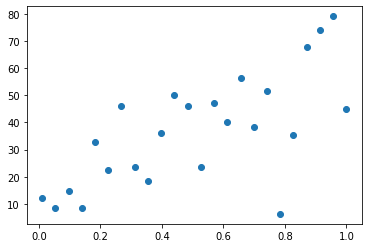

In [1207]:
plt.scatter(x, y);

In [1208]:
X = list(zip(np.ones(24), np.log(x)))

In [1209]:
W = np.linalg.lstsq(X, y, rcond=None)[0]
print (W)

[49.18970248 12.03689879]


In [1210]:
def f(x, w): 
    return w[0] + w[1]*np.log(x)

In [1211]:
f(x, W)

array([-6.24226497, 13.8416236 , 20.99324659, 25.44880451, 28.69334967,
       31.24642793, 33.35160668, 35.14283135, 36.70170539, 38.08164506,
       39.31953096, 40.44189919, 41.46848138, 42.41434898, 43.29127432,
       44.10862834, 44.87399235, 45.59358659, 46.27257773, 46.91530413,
       47.52544394, 48.10614265, 48.66011118, 49.18970248])

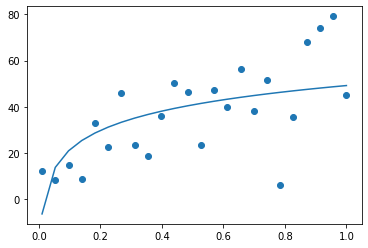

In [1212]:
plt.scatter(x, y)
plt.plot(x, f(x, W));

In [1213]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, f(x, W)))

Среднеквадратичная ошибка: 246.11565235289538


## Вариант 2

In [1214]:
y = np.array([12.19, 8.41, 14.68, 8.64, 32.94, 22.61, 45.92, 23.63, 18.59, 36.22, 50.10, 46.22, 23.63, 47.30, 40.03, 56.53, 38.41, 51.47, 6.29, 35.41, 67.79, 74.21, 79.12, 45.10])
x = np.linspace(0.01, 1, num = 24)

In [1215]:
X = np.polyfit(np.log(x), y, 1)
print(X)

[12.03689879 49.18970248]


In [1216]:
exp_reg = X[1] + X[0]*np.log(x)

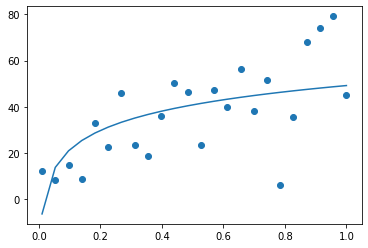

In [1217]:
plt.scatter(x, y)
plt.plot(x, exp_reg);

In [1218]:
print('Среднеквадратичная ошибка:', mean_squared_error(y, exp_reg))

Среднеквадратичная ошибка: 246.11565235289538


## Задача 2

Данные: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset 

1. Разделите данные на train/test или используйте кросс-валидацию (можно grid search)

2. Постройте несколько моделей линейной регрессии:
- sklearn.linear_model.LinearRegression
- sklearn.linear_model.Ridge
- sklearn.linear_model.Lasso
- sklearn.linear_model.ElasticNet
3. Для последних трёх вариантов попробуйте разные значения коэффициента регуляризации.
4. Сравните построенные модели по MSE на тестовой выборке (или через кросс-валидацию)
5. Какая модель оказалась наилучшей? Почему?

In [1219]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

X, y = datasets.load_diabetes(return_X_y=True)

In [1220]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [1221]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

Text(0, 0.5, 'Predictions')

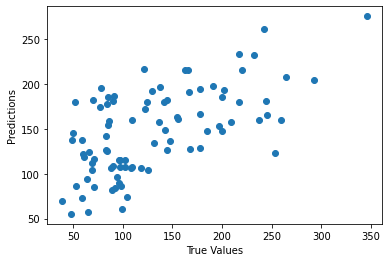

In [1222]:
plt.scatter(y_test, predictions)
plt.xlabel('True Values')
plt.ylabel('Predictions')

In [1223]:
print ('Score:', model.score(X_test, y_test))

Score: 0.3209433921053437


In [1224]:
a = model.coef_[0]
b = model.intercept_
print('Наклон линии (угловой коэффициент): ', a)
print('Точка пересечения (с осью Y): ', b)

Наклон линии (угловой коэффициент):  6.791624595689101
Точка пересечения (с осью Y):  155.32813176523763


In [1225]:
lin_reg = a*x + b

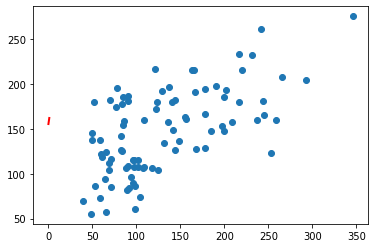

In [1226]:
plt.scatter(y_test, predictions)
plt.plot(x, lin_reg, color='red', linewidth=2);